# Credit Card Approval Prediction Using ML

### Introduction

This dataset pertains to Credit Card Approval Prediction, a classification task in the field of financial services. The goal is to predict whether a credit card application will be approved or rejected based on the applicant's attributes. The dataset consists of various features such as income, employment status, credit history, and other personal financial factors.

In this project, we will first perform data cleaning to address any missing values and inconsistencies. Following that, I will apply data balancing techniques to handle any class imbalances. Multiple machine learning algorithms will be trained on the preprocessed data to evaluate their performance. These models will then be fine-tuned to achieve the best possible results.

Once the model is optimized, I plan to build a web application that will provide real-time credit card approval predictions, allowing users to submit their details and receive an immediate decision on their application.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import  warnings 
warnings.filterwarnings('ignore')

In [2]:
# Load application data
app_df = pd.read_csv("../data/application_record.csv")


In [3]:
app_df.shape

(438557, 18)

In [4]:
app_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [5]:
app_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [6]:
app_df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [7]:
app_df.isna().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [8]:
app_df['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)

In [9]:
# Converting ages and days of employment into understandable numbers
app_df['AGE'] = (-app_df['DAYS_BIRTH']) // 365

In [10]:
app_df['YEARS_EMPLOYED'] = app_df['DAYS_EMPLOYED'].apply(lambda x: -1 if x == 365243 else (-x) // 365)

In [11]:
app_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,Unknown,1.0,62,-1
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0,43,8
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0,22,1
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,Unknown,2.0,59,-1


In [12]:
# Load credit record data
credit_df = pd.read_csv("../data/credit_record.csv")


In [13]:
credit_df.shape

(1048575, 3)

In [14]:
credit_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [15]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [16]:
credit_df.describe()

,ID,MONTHS_BALANCE
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


In [17]:
credit_df.isna().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [18]:
# Preparing the target column (label)
def define_target(status_list):
    return 0 if any(s in ['2','3','4','5'] for s in status_list) else 1

target_df = credit_df.groupby('ID')['STATUS'].apply(list).reset_index()
target_df['TARGET'] = target_df['STATUS'].apply(define_target)
target_df.drop('STATUS', axis=1, inplace=True)

In [19]:
target_df

,ID,TARGET
0,5001711,1
1,5001712,1
2,5001713,1
3,5001714,1
4,5001715,1
...,...,...
45980,5150482,1
45981,5150483,1
45982,5150484,1
45983,5150485,1


In [20]:
# Final data merge
merged_df = app_df.merge(target_df, on='ID', how='inner')

In [21]:
print(f"Final shape: {merged_df.shape}")
merged_df.head()

Final shape: (36457, 21)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,YEARS_EMPLOYED,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,32,12,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,32,12,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,-1134,1,0,0,0,Security staff,2.0,58,3,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,52,8,1
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,52,8,1


In [22]:
merged_df.isna().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
AGE                    0
YEARS_EMPLOYED         0
TARGET                 0
dtype: int64

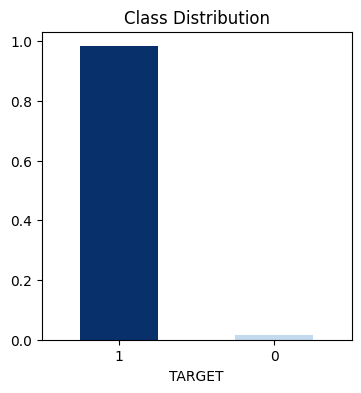

In [23]:
# Data balance check
plt.figure(figsize=(4, 4))
plt.tick_params(axis='x', rotation=0)

merged_df['TARGET'].value_counts(normalize=True).plot(
    kind='bar',
    title='Class Distribution',
    color=['#08306b', '#c3daee']
)
plt.tick_params(axis='x', rotation=0)

Convert categorical columns to numeric values using ColumnTransformer with OneHotEncoder

In [24]:
# Importing necessary libraries
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

Separating Features from the Target

In [25]:
# Set B — 10 features (chosen via feature selection experiments)
X = merged_df[[
    'AMT_INCOME_TOTAL', 'AGE', 'YEARS_EMPLOYED', 'CNT_FAM_MEMBERS',
    'CODE_GENDER', 'FLAG_OWN_CAR', 'NAME_EDUCATION_TYPE',
    'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS',
]]

y = merged_df['TARGET']


In [26]:
X.head()

,AMT_INCOME_TOTAL,AGE,YEARS_EMPLOYED,CNT_FAM_MEMBERS,CODE_GENDER,FLAG_OWN_CAR,NAME_EDUCATION_TYPE,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_FAMILY_STATUS
0,427500.0,32,12,2.0,M,Y,Higher education,Y,Working,Civil marriage
1,427500.0,32,12,2.0,M,Y,Higher education,Y,Working,Civil marriage
2,112500.0,58,3,2.0,M,Y,Secondary / secondary special,Y,Working,Married
3,270000.0,52,8,1.0,F,N,Secondary / secondary special,Y,Commercial associate,Single / not married
4,270000.0,52,8,1.0,F,N,Secondary / secondary special,Y,Commercial associate,Single / not married


In [27]:
# Set B — column type definitions
numerical_cols = ['AMT_INCOME_TOTAL', 'AGE', 'YEARS_EMPLOYED', 'CNT_FAM_MEMBERS']
categorical_cols = [
    'CODE_GENDER', 'FLAG_OWN_CAR', 'NAME_EDUCATION_TYPE',
    'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS',
]


In [28]:
# Splitting data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [29]:
# Remove outliers from training data only
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

In [30]:
# Apply the function to X_train and update y_train based on the indexes
X_train_clean = remove_outliers_iqr(X_train.copy(), numerical_cols)
y_train_clean = y_train.loc[X_train_clean.index]

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    # handle_unknown='ignore': guards against unseen categories at inference time
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
])


In [32]:
# Transform training and test data
X_train_transformed = preprocessor.fit_transform(X_train_clean)
X_test_transformed = preprocessor.transform(X_test)

Data balancing using SMOTE

In [33]:
# Using SMOTE for data balancing
smote = SMOTE(random_state=42)

In [34]:
# Applying SMOTE on transferred data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train_clean)

Check the balance after balancing

In [35]:
print(f"Before resampling:\n{y_train_clean.value_counts()}")

Before resampling:
TARGET
1    22382
0      397
Name: count, dtype: int64


In [36]:
print(f"After resampling:\n{y_train_resampled.value_counts()}")

After resampling:
TARGET
1    22382
0    22382
Name: count, dtype: int64


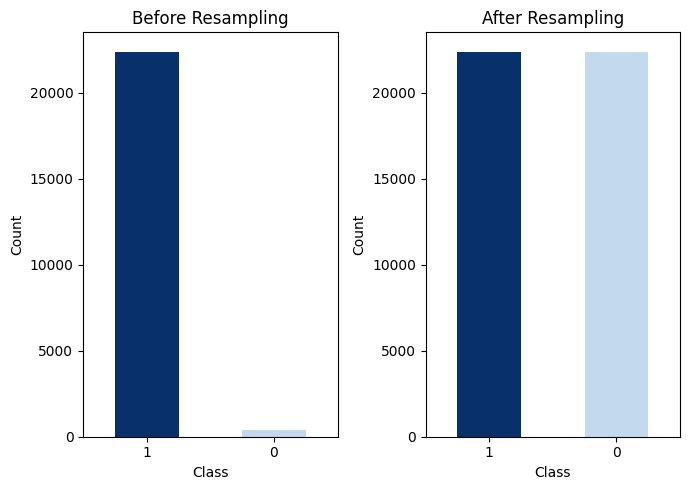

In [37]:
# Data before and after resampling
before_resampling = y_train_clean.value_counts()
after_resampling = y_train_resampled.value_counts()

# Plot to compare before and after resampling
plt.figure(figsize=(7, 5))

# Plot data before resampling
plt.subplot(1, 2, 1)
before_resampling.plot(kind='bar', color=['#08306b', '#c3daee'])
plt.title('Before Resampling')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tick_params(axis='x', rotation=0)

# Plot data after resampling
plt.subplot(1, 2, 2)
after_resampling.plot(kind='bar', color=['#08306b', '#c3daee'])
plt.title('After Resampling')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [38]:
# Merge balanced data into a unified DataFrame
df = pd.DataFrame(X_train_resampled.toarray() if hasattr(X_train_resampled, "toarray") else X_train_resampled)

# Rename columns using the column names generated by the preprocessor
# Obtain column names from each Transformer
num_features = preprocessor.named_transformers_['num'].get_feature_names_out(numerical_cols)
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
df.columns = np.concatenate([num_features, cat_features])

# Add target column
df['TARGET'] = y_train_resampled.values

In [39]:
df

,AMT_INCOME_TOTAL,AGE,YEARS_EMPLOYED,CNT_FAM_MEMBERS,CODE_GENDER_M,FLAG_OWN_CAR_Y,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,FLAG_OWN_REALTY_Y,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Working,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,TARGET
0,-0.532061,-0.512656,0.157422,-0.196418,0.0,0.0,0.000000,0.0,0.0,1.000000,0.000000,0.000000,0.0,0.0,1.000000,1.0,0.0,0.0,0.0,1
1,2.002905,-1.277867,-0.696776,-1.387000,1.0,1.0,1.000000,0.0,0.0,0.000000,1.000000,0.000000,0.0,0.0,1.000000,0.0,0.0,1.0,0.0,1
2,2.002905,0.507625,0.798072,-1.387000,0.0,1.0,0.000000,0.0,0.0,1.000000,1.000000,0.000000,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,1
3,0.101680,-0.597680,1.225171,-0.196418,0.0,0.0,0.000000,0.0,0.0,1.000000,1.000000,0.000000,1.0,0.0,0.000000,0.0,0.0,1.0,0.0,1
4,1.052293,-0.682703,0.157422,0.994164,1.0,1.0,0.000000,0.0,0.0,1.000000,0.000000,0.000000,0.0,0.0,1.000000,1.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44759,1.801365,-0.427633,1.536072,-1.387000,1.0,1.0,0.636032,0.0,0.0,0.363968,0.363968,0.636032,0.0,0.0,0.363968,0.0,0.0,1.0,0.0,0
44760,-0.806024,1.160354,-1.123876,-1.387000,0.0,0.0,0.000000,0.0,0.0,1.000000,1.000000,1.000000,0.0,0.0,0.000000,0.0,0.0,0.0,1.0,0
44761,0.418551,1.017765,1.225171,-0.196418,0.0,0.0,0.000000,0.0,0.0,1.000000,1.000000,0.000000,0.0,0.0,1.000000,1.0,0.0,0.0,0.0,0
44762,1.256888,-1.126565,0.382742,0.994164,0.0,1.0,1.000000,0.0,0.0,0.000000,0.944884,0.000000,0.0,0.0,1.000000,1.0,0.0,0.0,0.0,0


In [40]:
# Value counts for target (adjust if different name)
print("\nTarget Distribution:\n", df.iloc[:, -1].value_counts())


Target Distribution:
 TARGET
1    22382
0    22382
Name: count, dtype: int64


## Feature Selection Experiments

Three feature sets (A, B, C) are tested with the same Random Forest pipeline
and the same train/test split (`test_size=0.3`, `random_state=42`).
Results determine the feature set used in the final deployed model.

| Set | Features | Description |
|---|---|---|
| A | 7 | Current baseline |
| B | 10 | Adds property ownership, income type, family status |
| C | 14 | Adds housing type, occupation, children count, income-per-member (derived) |


In [41]:
# Derived feature: per-capita income
# CNT_FAM_MEMBERS minimum is 1.0 (verified via describe()) — no division-by-zero risk
merged_df['INCOME_PER_FAM_MEMBER'] = (
    merged_df['AMT_INCOME_TOTAL'] / merged_df['CNT_FAM_MEMBERS']
)
print('INCOME_PER_FAM_MEMBER added. Sample stats:')
print(merged_df['INCOME_PER_FAM_MEMBER'].describe().round(2))


INCOME_PER_FAM_MEMBER added. Sample stats:
count     36457.00
mean     100554.77
std       72678.93
min        5625.00
25%       56250.00
50%       78750.00
75%      123750.00
max      900000.00
Name: INCOME_PER_FAM_MEMBER, dtype: float64


In [42]:
FEATURE_SETS = {
    'Set A — 7 features (baseline)': {
        'num': ['AMT_INCOME_TOTAL', 'AGE', 'YEARS_EMPLOYED', 'CNT_FAM_MEMBERS'],
        'cat': ['CODE_GENDER', 'FLAG_OWN_CAR', 'NAME_EDUCATION_TYPE'],
    },
    'Set B — 10 features (improved)': {
        'num': ['AMT_INCOME_TOTAL', 'AGE', 'YEARS_EMPLOYED', 'CNT_FAM_MEMBERS'],
        'cat': ['CODE_GENDER', 'FLAG_OWN_CAR', 'NAME_EDUCATION_TYPE',
                'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS'],
    },
    'Set C — 14 features (broad)': {
        'num': ['AMT_INCOME_TOTAL', 'AGE', 'YEARS_EMPLOYED', 'CNT_FAM_MEMBERS',
                'CNT_CHILDREN', 'INCOME_PER_FAM_MEMBER'],
        'cat': ['CODE_GENDER', 'FLAG_OWN_CAR', 'NAME_EDUCATION_TYPE',
                'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS',
                'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'],
    },
}

# IQR outlier removal is applied only to these 4 columns across all sets
# — keeps the same rows removed in every experiment for a fair comparison
OUTLIER_COLS = ['AMT_INCOME_TOTAL', 'AGE', 'YEARS_EMPLOYED', 'CNT_FAM_MEMBERS']

print('Feature sets defined:')
for name, cols in FEATURE_SETS.items():
    total = len(cols['num']) + len(cols['cat'])
    print(f'  {name}: {total} features ({len(cols["num"])} num, {len(cols["cat"])} cat)')


Feature sets defined:
  Set A — 7 features (baseline): 7 features (4 num, 3 cat)
  Set B — 10 features (improved): 10 features (4 num, 6 cat)
  Set C — 14 features (broad): 14 features (6 num, 8 cat)


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score,
    recall_score, classification_report,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

exp_results = {}

for set_name, cols in FEATURE_SETS.items():
    num_cols = cols['num']
    cat_cols = cols['cat']
    all_cols = num_cols + cat_cols

    X_exp = merged_df[all_cols]
    y_exp = merged_df['TARGET']

    # Identical split for every experiment
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_exp, y_exp, test_size=0.3, random_state=42
    )

    # IQR outlier removal on the fixed 4 original numerical cols only
    iqr_cols = [c for c in OUTLIER_COLS if c in num_cols]
    X_tr_clean = remove_outliers_iqr(X_tr.copy(), iqr_cols)
    y_tr_clean  = y_tr.loc[X_tr_clean.index]

    pre = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        # handle_unknown='ignore' is required for OCCUPATION_TYPE in Set C:
        # rare categories may appear in test but not in the cleaned training set
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ])

    pipe = ImbPipeline([
        ('preprocessor', pre),
        ('smote', SMOTE(random_state=42)),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ])

    pipe.fit(X_tr_clean, y_tr_clean)
    y_pred = pipe.predict(X_te)
    y_prob = pipe.predict_proba(X_te)[:, 1]

    exp_results[set_name] = {
        'Macro F1':    round(f1_score(y_te, y_pred, average='macro'), 4),
        'ROC-AUC':     round(roc_auc_score(y_te, y_prob), 4),
        'Precision-0': round(precision_score(y_te, y_pred, pos_label=0), 4),
        'Recall-0':    round(recall_score(y_te, y_pred, pos_label=0), 4),
    }

    print(f'\n{"="*58}')
    print(f'  {set_name}')
    print('='*58)
    print(classification_report(
        y_te, y_pred,
        target_names=['Rejected (0)', 'Approved (1)'],
    ))



  Set A — 7 features (baseline)
              precision    recall  f1-score   support

Rejected (0)       0.31      0.27      0.29       179
Approved (1)       0.99      0.99      0.99     10759

    accuracy                           0.98     10938
   macro avg       0.65      0.63      0.64     10938
weighted avg       0.98      0.98      0.98     10938


  Set B — 10 features (improved)
              precision    recall  f1-score   support

Rejected (0)       0.35      0.26      0.30       179
Approved (1)       0.99      0.99      0.99     10759

    accuracy                           0.98     10938
   macro avg       0.67      0.63      0.65     10938
weighted avg       0.98      0.98      0.98     10938


  Set C — 14 features (broad)
              precision    recall  f1-score   support

Rejected (0)       0.37      0.25      0.30       179
Approved (1)       0.99      0.99      0.99     10759

    accuracy                           0.98     10938
   macro avg       0.68      0

In [44]:
import pandas as pd

summary = pd.DataFrame(exp_results).T
summary.index.name = 'Feature Set'

print('\n' + '='*58)
print('  FEATURE SET COMPARISON SUMMARY')
print('='*58)
print(summary.to_string())
print()

for metric in summary.columns:
    best_idx = summary[metric].idxmax()
    best_val = summary[metric].max()
    print(f'  Best {metric:12s}: {best_idx}  ({best_val})')

print()
print('Decision rule:')
print('  Primary  — highest ROC-AUC (gain >= 0.005 over Set A is meaningful)')
print('  Checks   — Recall-0 must not drop vs Set A; Precision-0 must stay >= 0.45')
print('  Tiebreak — prefer smaller set when ROC-AUC difference < 0.003')



  FEATURE SET COMPARISON SUMMARY
                                Macro F1  ROC-AUC  Precision-0  Recall-0
Feature Set                                                             
Set A — 7 features (baseline)     0.6382   0.7529       0.3097    0.2682
Set B — 10 features (improved)    0.6451   0.7524       0.3507    0.2626
Set C — 14 features (broad)       0.6428   0.7712       0.3697    0.2458

  Best Macro F1    : Set B — 10 features (improved)  (0.6451)
  Best ROC-AUC     : Set C — 14 features (broad)  (0.7712)
  Best Precision-0 : Set C — 14 features (broad)  (0.3697)
  Best Recall-0    : Set A — 7 features (baseline)  (0.2682)

Decision rule:
  Primary  — highest ROC-AUC (gain >= 0.005 over Set A is meaningful)
  Checks   — Recall-0 must not drop vs Set A; Precision-0 must stay >= 0.45
  Tiebreak — prefer smaller set when ROC-AUC difference < 0.003


## Model Training

Final feature set: **Set B — 10 features** (selected via the experiments above).
An `ImbPipeline` applies SMOTE only during `fit()` and skips it at `predict()` time.
The pipeline accepts raw 10-feature input — no separate preprocessing step at inference.

**Numerical (4):** `AMT_INCOME_TOTAL`, `AGE`, `YEARS_EMPLOYED`, `CNT_FAM_MEMBERS`  
**Categorical (6):** `CODE_GENDER`, `FLAG_OWN_CAR`, `NAME_EDUCATION_TYPE`,
`FLAG_OWN_REALTY`, `NAME_INCOME_TYPE`, `NAME_FAMILY_STATUS`


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
])

rf_pipeline.fit(X_train_clean, y_train_clean)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print('===== Random Forest =====')
print(classification_report(y_test, y_pred_rf))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob_rf), 4))


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.35      0.26      0.30       179
           1       0.99      0.99      0.99     10759

    accuracy                           0.98     10938
   macro avg       0.67      0.63      0.65     10938
weighted avg       0.98      0.98      0.98     10938

ROC-AUC: 0.7524


In [46]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', KNeighborsClassifier(n_neighbors=5)),
])

knn_pipeline.fit(X_train_clean, y_train_clean)

y_pred_knn = knn_pipeline.predict(X_test)
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

print('===== KNN =====')
print(classification_report(y_test, y_pred_knn))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob_knn), 4))


===== KNN =====
              precision    recall  f1-score   support

           0       0.12      0.27      0.17       179
           1       0.99      0.97      0.98     10759

    accuracy                           0.96     10938
   macro avg       0.55      0.62      0.57     10938
weighted avg       0.97      0.96      0.96     10938

ROC-AUC: 0.675


In [47]:
from sklearn.metrics import accuracy_score

models = {
    'Random Forest': (y_pred_rf, y_prob_rf),
    'KNN':           (y_pred_knn, y_prob_knn),
}

print(f"{'Model':<20} {'Accuracy':>10} {'ROC-AUC':>10}")
print('-' * 42)
for name, (y_pred, y_prob) in models.items():
    acc = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)
    print(f"{name:<20} {acc:>10.4f} {auc_score:>10.4f}")


Model                  Accuracy    ROC-AUC
------------------------------------------
Random Forest            0.9800     0.7524
KNN                      0.9557     0.6750


In [48]:
import joblib, os

# Random Forest is the chosen final model (Set B — 10 features)
# Change to knn_pipeline here if KNN outperforms RF on Set B
final_pipeline = rf_pipeline

os.makedirs('../model_artifacts', exist_ok=True)
joblib.dump(final_pipeline, '../model_artifacts/pipeline.pkl')
print('Saved: model_artifacts/pipeline.pkl')
print(f'  Model : RandomForestClassifier')
print(f'  Features: Set B — 10 features')
print(f'  Steps : preprocessor -> smote -> clf')


Saved: model_artifacts/pipeline.pkl
  Model : RandomForestClassifier
  Features: Set B — 10 features
  Steps : preprocessor -> smote -> clf
